# Live VGGT Inference Demo

VGGT receives one or more RGB images of the same scene and jointly predicts camera intrinsics/extrinsics, depth and depth confidence, direct point maps and point confidence, plus optional point tracks. This presentation uses the official 1B research checkpoint from a verified local file with Hugging Face offline mode enabled. It is a live functional demonstration, not a benchmark.

The initial scene is the official bundled single-cartoon example. Later, change `SCENE_DIR` to a folder of overlapping multi-view photographs. Run cells in order and read the explanatory text before each expensive stage.

## 1. Imports and project paths
Offline flags are set before model-related imports. Root discovery uses repository markers rather than a user-specific path.

In [1]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

import gc, json, platform, subprocess, sys, time
from pathlib import Path

def discover_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "configs/default.yaml").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate the VGGT seminar root from {current}")

ROOT = discover_root()
for import_root in (ROOT / "src", ROOT / "external/vggt"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

import cv2
import numpy as np
import torch
import yaml
from IPython.display import HTML, display
from PIL import Image, ImageDraw

from vggt_seminar.live_demo import (center_or_explicit_query, discover_images, heatmap_rgb,
    point_cloud_preview, prediction_schema, save_heatmap, save_ply, verify_local_assets)
from vggt.models.vggt import VGGT
from vggt.utils.geometry import unproject_depth_map_to_point_map
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri

SEED = 42
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print(f"Project root: {ROOT}")

d:\cv_sem\.micromamba\envs\vggt-seminar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\cv_sem


## 2. Editable configuration
For a new scene, point `SCENE_DIR` at a directory containing only the desired views. `MAX_IMAGES=None` uses every matching image. Set a new `RUN_NAME` before exporting again.

In [2]:
SCENE_DIR = ROOT / "external/vggt/examples/single_cartoon/images"
IMAGE_GLOB = "*"
DEVICE = "cuda"
USE_BFLOAT16 = True
ENABLE_TRACKING = True
TRACK_QUERY_XY = None  # None means image center; otherwise use (x, y) after preprocessing
MAX_IMAGES = None
EXPORT_RESULTS = True
RUN_NAME = "notebook_live_demo"
PREPROCESSING_MODE = "crop"  # official helper accepts "crop" or "pad"
assert DEVICE == "cuda", "This notebook intentionally refuses silent CPU fallback."

## 3. Environment, repository, and checkpoint verification
This cell hashes the full 5 GB checkpoint, so it may take a little while. It fails before model allocation if CUDA, the code pin, or checkpoint integrity is wrong.

In [3]:
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable; no CPU fallback is permitted.")
assets = verify_local_assets(ROOT)
gpu = torch.cuda.get_device_properties(0)
rows = {
    "Python": platform.python_version(), "PyTorch": torch.__version__,
    "PyTorch CUDA runtime": torch.version.cuda, "CUDA available": torch.cuda.is_available(),
    "GPU": torch.cuda.get_device_name(0), "Compute capability": torch.cuda.get_device_capability(0),
    "bfloat16 supported": torch.cuda.is_bf16_supported(), "Total VRAM (GiB)": f"{gpu.total_memory / 2**30:.2f}",
    "Pinned VGGT commit": assets["checkout"]["commit"], "Checkpoint exists": assets["checkpoint"].is_file(),
    "Checkpoint size (GiB)": f"{assets['checkpoint_size_bytes'] / 2**30:.3f}",
    "Checkpoint SHA-256 verified": assets["checkpoint_hash_matches"],
}
display(HTML("<table>" + "".join(f"<tr><th style='text-align:left;padding:4px'>{k}</th><td style='padding:4px'>{v}</td></tr>" for k,v in rows.items()) + "</table>"))

Python,3.11.15
PyTorch,2.13.0+cu130
PyTorch CUDA runtime,13.0
CUDA available,True
GPU,NVIDIA GeForce RTX 5080
Compute capability,"(12, 0)"
bfloat16 supported,True
Total VRAM (GiB),15.92
Pinned VGGT commit,a288dd0f14786c93483e45524328726ab7b1b4ce
Checkpoint exists,True
Checkpoint size (GiB),4.682


## 4. Select and display input images
The first image is the reference frame. For multi-view scenes, order therefore deserves deliberate attention.

Selected 1 image(s):
  00: external\vggt\examples\single_cartoon\images\model_was_never_trained_on_single_image_or_cartoon.jpg


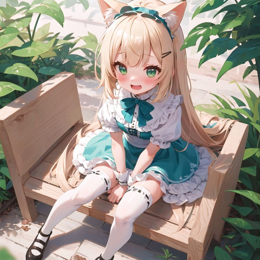

In [4]:
image_paths = discover_images(Path(SCENE_DIR), IMAGE_GLOB, MAX_IMAGES)
print(f"Selected {len(image_paths)} image(s):")
for index, path in enumerate(image_paths): print(f"  {index:02d}: {path.relative_to(ROOT)}")
thumbs = []
for path in image_paths:
    image = Image.open(path).convert("RGB"); image.thumbnail((360, 260)); thumbs.append(image.copy())
display(*thumbs)

## 5. Official VGGT preprocessing
The official helper converts images to RGB, rescales to the 518-pixel target, and ensures patch-compatible dimensions. The tensor remains on CPU until the model is ready.

Preprocessed: shape=(1, 3, 518, 518), dtype=torch.float32, range=(0.000, 1.000)


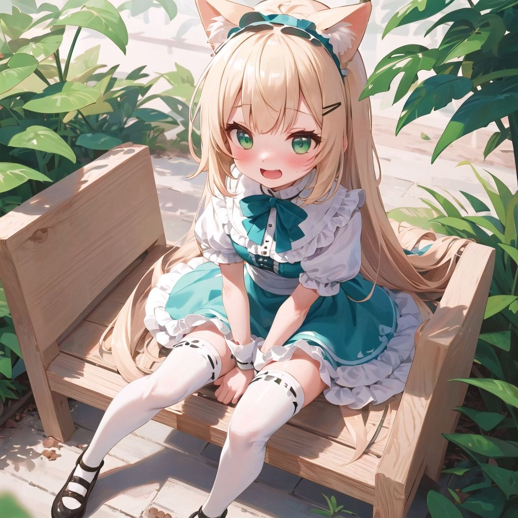

In [5]:
images_cpu = load_and_preprocess_images(image_paths, mode=PREPROCESSING_MODE)
print(f"Preprocessed: shape={tuple(images_cpu.shape)}, dtype={images_cpu.dtype}, range=({images_cpu.min():.3f}, {images_cpu.max():.3f})")
preview = Image.fromarray((images_cpu[0].permute(1,2,0).numpy().clip(0,1) * 255).astype(np.uint8))
display(preview)

## 6. Initialize the official architecture
This constructs the 1B-parameter architecture on CPU without contacting Hugging Face.

In [6]:
architecture_start = time.perf_counter()
model = VGGT()
architecture_init_seconds = time.perf_counter() - architecture_start
parameter_count = sum(p.numel() for p in model.parameters())
print(f"Architecture initialized in {architecture_init_seconds:.3f}s with {parameter_count/1e9:.3f}B parameters")

Architecture initialized in 5.529s with 1.257B parameters


## 7. Load the verified local checkpoint
Memory-mapped, weights-only deserialization avoids the model hub and reduces unnecessary CPU copies.

In [7]:
checkpoint_start = time.perf_counter()
state_dict = torch.load(assets["checkpoint"], map_location="cpu", weights_only=True, mmap=True)
load_result = model.load_state_dict(state_dict, strict=True)
del state_dict
checkpoint_load_seconds = time.perf_counter() - checkpoint_start
print(f"Checkpoint loaded in {checkpoint_load_seconds:.3f}s; {load_result}")

Checkpoint loaded in 1.344s; <All keys matched successfully>


## 8. Move model and inputs to the RTX 5080
The model remains in float32 storage; bfloat16 autocast is applied during the forward pass.

In [8]:
device = torch.device(DEVICE + ":0")
torch.cuda.set_device(0)
transfer_start = time.perf_counter()
model = model.to(device).eval()
images = images_cpu.to(device)
torch.cuda.synchronize()
gpu_transfer_seconds = time.perf_counter() - transfer_start
height, width = images.shape[-2:]
query_points = center_or_explicit_query(width, height, TRACK_QUERY_XY, device) if ENABLE_TRACKING else None
print(f"Model and {len(image_paths)} image(s) moved to {device} in {gpu_transfer_seconds:.3f}s")
print(f"Tracking query: {query_points.cpu().tolist() if query_points is not None else 'disabled'}")

Model and 1 image(s) moved to cuda:0 in 1.118s
Tracking query: [[[259.0, 259.0]]]


## 9. One live inference
This is the only forward-pass cell. CUDA synchronization makes elapsed time and peak allocated VRAM meaningful for this run; it is still not a formal benchmark.

In [9]:
torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(0)
baseline_gpu_memory_bytes = torch.cuda.memory_allocated(0)
inference_start = time.perf_counter()
autocast_dtype = torch.bfloat16 if USE_BFLOAT16 else torch.float16
with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=autocast_dtype):
    predictions = model(images, query_points=query_points)
torch.cuda.synchronize()
inference_seconds = time.perf_counter() - inference_start
peak_gpu_memory_bytes = torch.cuda.max_memory_allocated(0)
print(f"Inference completed in {inference_seconds:.3f}s; peak allocated VRAM={peak_gpu_memory_bytes/2**30:.3f} GiB")

D:\cv_sem\external\vggt\vggt\models\vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Inference completed in 1.177s; peak allocated VRAM=5.347 GiB


## 10. Inspect and validate output tensors
Every output is checked for NaNs and infinities. Tracking fields appear only when tracking was enabled.

In [10]:
schema = prediction_schema(predictions)
bad = [name for name, info in schema["outputs"].items() if (info.get("finite") is False or any(item["finite"] is False for item in info.get("items", [])))]
if bad: raise RuntimeError(f"Non-finite outputs: {bad}")
table_rows = []
for name, info in schema["outputs"].items():
    summary = f"list[{info['length']}]" if info.get("type") == "tensor_list" else str(info["shape"])
    dtype = info["items"][0]["dtype"] if info.get("type") == "tensor_list" else info["dtype"]
    finite = all(x["finite"] for x in info["items"]) if info.get("type") == "tensor_list" else info["finite"]
    table_rows.append((name, summary, dtype, finite))
display(HTML("<table><tr><th>Output</th><th>Shape</th><th>dtype</th><th>Finite</th></tr>" + "".join(f"<tr><td>{a}</td><td>{b}</td><td>{c}</td><td>{d}</td></tr>" for a,b,c,d in table_rows) + "</table>"))

Output,Shape,dtype,Finite
pose_enc,"[1, 1, 9]",torch.float32,True
pose_enc_list,list[4],torch.float32,True
depth,"[1, 1, 518, 518, 1]",torch.float32,True
depth_conf,"[1, 1, 518, 518]",torch.float32,True
world_points,"[1, 1, 518, 518, 3]",torch.float32,True
world_points_conf,"[1, 1, 518, 518]",torch.float32,True
track,"[1, 1, 1, 2]",torch.float32,True
vis,"[1, 1, 1]",torch.bfloat16,True
conf,"[1, 1, 1]",torch.bfloat16,True
images,"[1, 1, 3, 518, 518]",torch.float32,True


## 11. Decode camera outputs
VGGT predicts a compact 9D camera encoding. The official utility decodes it to OpenCV-style camera-from-world extrinsics and intrinsics.

In [11]:
pose_enc = predictions["pose_enc"].float()
extrinsic, intrinsic = pose_encoding_to_extri_intri(pose_enc, images.shape[-2:])
print("Extrinsics [B,S,3,4]:", extrinsic.cpu().numpy())
print("Intrinsics [B,S,3,3]:", intrinsic.cpu().numpy())

Extrinsics [B,S,3,4]: [[[[ 1.  0.  0. -0.]
   [-0.  1. -0.  0.]
   [-0.  0.  1. -0.]]]]
Intrinsics [B,S,3,3]: [[[[687.5347   0.     259.    ]
   [  0.     689.5708 259.    ]
   [  0.       0.       1.    ]]]]


## 12. Depth and confidence maps
Colors are percentile-normalized for display only; raw tensors remain unchanged.

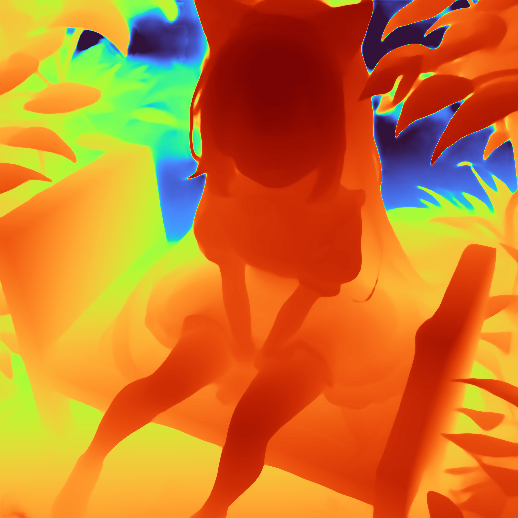

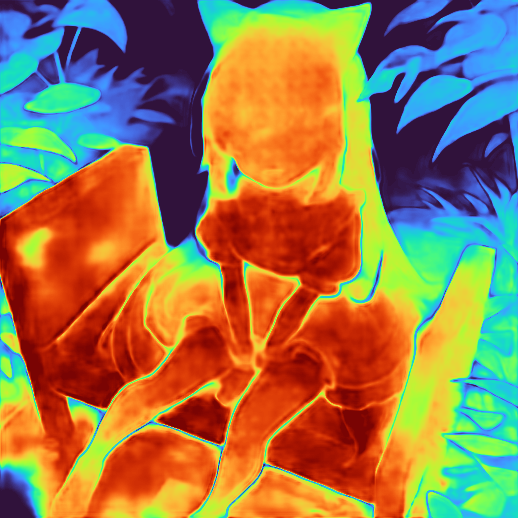

In [12]:
for view in range(len(image_paths)):
    display(HTML(f"<h4>View {view}: depth</h4>"), Image.fromarray(heatmap_rgb(predictions['depth'][0, view], invert=True)))
    display(HTML(f"<h4>View {view}: depth confidence</h4>"), Image.fromarray(heatmap_rgb(predictions['depth_conf'][0, view])))

## 13. Direct and depth-unprojected point maps
The direct point head and the geometry derived from depth plus cameras are preserved separately.

Direct point map: (1, 1, 518, 518, 3) -0.7268289 1.975669
Depth-unprojected map: (1, 518, 518, 3) -0.7126333762019392 2.166177524155743


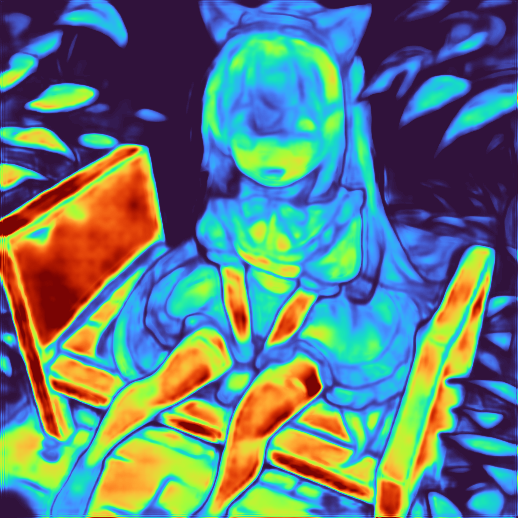

In [13]:
direct_points = predictions["world_points"].float().cpu().numpy()
unprojected_points = unproject_depth_map_to_point_map(
    predictions["depth"].float().squeeze(0).cpu().numpy(),
    extrinsic.squeeze(0).cpu().numpy(), intrinsic.squeeze(0).cpu().numpy())
print("Direct point map:", direct_points.shape, np.nanmin(direct_points), np.nanmax(direct_points))
print("Depth-unprojected map:", unprojected_points.shape, np.nanmin(unprojected_points), np.nanmax(unprojected_points))
display(HTML("<h4>Direct point confidence, view 0</h4>"), Image.fromarray(heatmap_rgb(predictions['world_points_conf'][0,0])))

## 14. Inline point-cloud previews
These lightweight orthographic previews use only existing dependencies. They are orientation aids, not substitutes for an interactive 3D viewer.

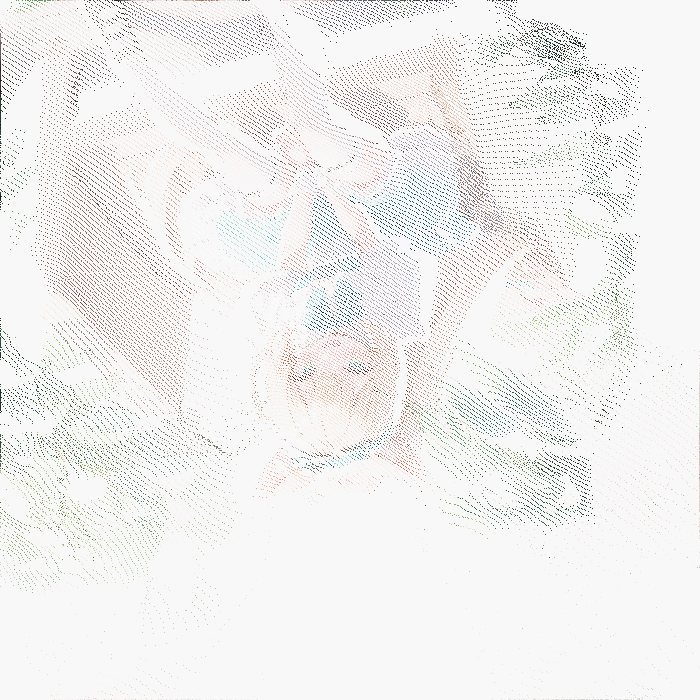

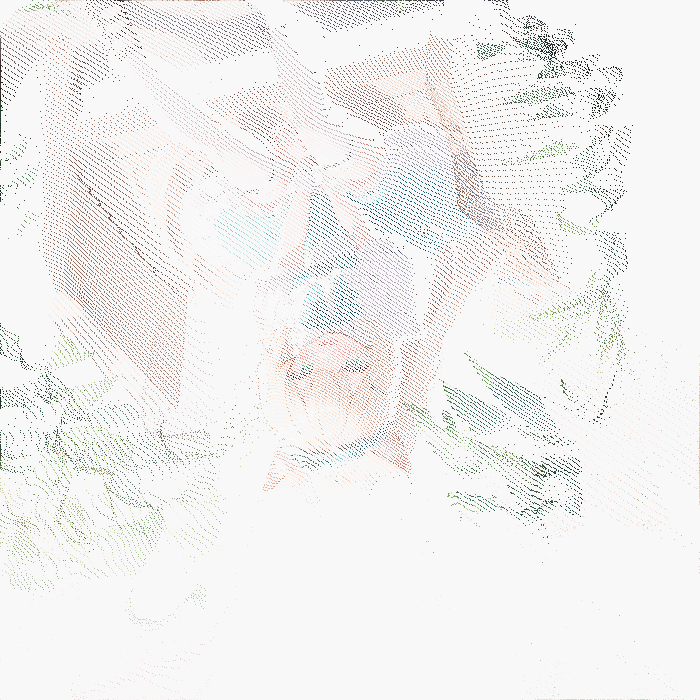

In [14]:
colors = predictions["images"][0].permute(0,2,3,1).float().cpu().numpy()
display(HTML("<h4>Direct point-map preview</h4>"), point_cloud_preview(direct_points[0], colors))
display(HTML("<h4>Depth-unprojected preview</h4>"), point_cloud_preview(unprojected_points, colors))

## 15. Optional point tracking
For a single image, the center query is expected to remain stationary. Multi-view scenes make this output more informative.

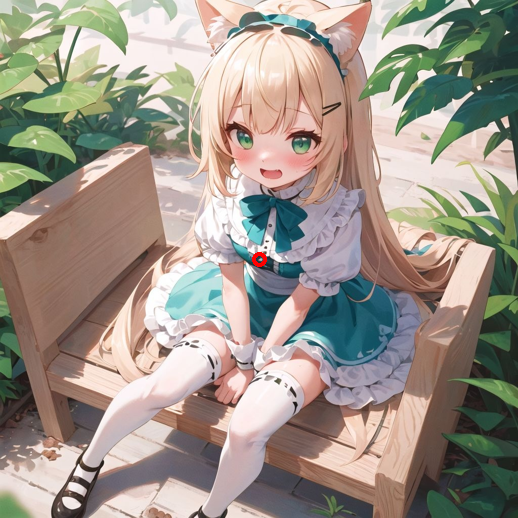

In [15]:
if not ENABLE_TRACKING:
    print("Tracking disabled. Set ENABLE_TRACKING=True and rerun from the inference cell to enable it.")
else:
    for view, image_path in enumerate(image_paths):
        frame = Image.fromarray((predictions['images'][0,view].permute(1,2,0).float().cpu().numpy().clip(0,1)*255).astype(np.uint8))
        draw = ImageDraw.Draw(frame); x,y = predictions['track'][0,view,0].float().cpu().tolist()
        draw.ellipse((x-7,y-7,x+7,y+7), outline='red', width=4)
        display(HTML(f"<b>View {view}: track=({x:.1f},{y:.1f}), visibility={float(predictions['vis'][0,view,0]):.3f}, confidence={float(predictions['conf'][0,view,0]):.3f}</b>"), frame)

## 16. Runtime and peak VRAM
These are live-run diagnostics. Repeatable benchmarking requires warm-up and a separate protocol.

In [16]:
runtime = {"architecture init (s)": architecture_init_seconds, "checkpoint load (s)": checkpoint_load_seconds,
           "GPU transfer (s)": gpu_transfer_seconds, "inference (s)": inference_seconds,
           "baseline allocated (GiB)": baseline_gpu_memory_bytes/2**30,
           "peak allocated (GiB)": peak_gpu_memory_bytes/2**30,
           "inference increment (GiB)": (peak_gpu_memory_bytes-baseline_gpu_memory_bytes)/2**30}
display(HTML("<table>" + "".join(f"<tr><th style='text-align:left'>{k}</th><td>{v:.4f}</td></tr>" for k,v in runtime.items()) + "</table>"))

architecture init (s),5.5289
checkpoint load (s),1.3442
GPU transfer (s),1.1181
inference (s),1.1766
baseline allocated (GiB),4.6891
peak allocated (GiB),5.3468
inference increment (GiB),0.6577


## 17. Optional export
Export preserves every raw model output, decoded cameras, both point clouds, configuration, schema, and runtime. Existing run directories are never overwritten.

In [17]:
if not EXPORT_RESULTS:
    print("Export disabled.")
else:
    run_dir = ROOT / "outputs/predictions" / RUN_NAME
    if run_dir.exists(): raise FileExistsError(f"Refusing to overwrite {run_dir}; choose a new RUN_NAME")
    raw_dir, vis_dir = run_dir / "raw", run_dir / "visualizations"
    raw_dir.mkdir(parents=True); vis_dir.mkdir()
    for name, value in predictions.items():
        if isinstance(value, torch.Tensor): torch.save(value.detach().cpu(), raw_dir / f"{name}.pt")
        elif isinstance(value, list):
            for i, item in enumerate(value): torch.save(item.detach().cpu(), raw_dir / f"{name}_{i}.pt")
    derived = {"extrinsic": extrinsic, "intrinsic": intrinsic,
               "unprojected_points": torch.from_numpy(unprojected_points)}
    for name, value in derived.items(): torch.save(value.detach().cpu(), raw_dir / f"{name}.pt")
    export_schema = prediction_schema(predictions, derived)
    (run_dir / "output_schema.json").write_text(json.dumps(export_schema, indent=2)+"\n", encoding="utf-8")
    export_runtime = {**runtime, "image_count": len(image_paths), "offline": True,
                      "checkpoint_sha256": assets['checkpoint_sha256'], "vggt_commit": assets['pin']['commit']}
    (run_dir / "runtime.json").write_text(json.dumps(export_runtime, indent=2)+"\n", encoding="utf-8")
    config = {k: str(v) if isinstance(v, Path) else v for k,v in {"SCENE_DIR":SCENE_DIR,"IMAGE_GLOB":IMAGE_GLOB,"DEVICE":DEVICE,"USE_BFLOAT16":USE_BFLOAT16,"ENABLE_TRACKING":ENABLE_TRACKING,"TRACK_QUERY_XY":TRACK_QUERY_XY,"MAX_IMAGES":MAX_IMAGES,"RUN_NAME":RUN_NAME}.items()}
    (run_dir / "resolved_config.yaml").write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")
    input_rgb = predictions['images'][0,0].permute(1,2,0).float().cpu().numpy()
    save_heatmap(predictions['depth'][0,0], vis_dir/'depth.png', invert=True)
    save_heatmap(predictions['depth_conf'][0,0], vis_dir/'depth_confidence.png')
    save_heatmap(predictions['world_points_conf'][0,0], vis_dir/'point_confidence.png')
    save_ply(direct_points[0], colors, vis_dir/'point_cloud_direct.ply')
    save_ply(unprojected_points, colors, vis_dir/'point_cloud_depth_unprojected.ply')
    print(f"Exported: {run_dir.relative_to(ROOT)}")

FileExistsError: Refusing to overwrite D:\cv_sem\outputs\predictions\notebook_live_demo; choose a new RUN_NAME

## 18. GPU cleanup
Run this after finishing the live explanation. It releases Python references and asks PyTorch to return unused cached blocks.

In [ ]:
for name in ["model","predictions","images","images_cpu","query_points","pose_enc","extrinsic","intrinsic"]:
    globals().pop(name, None)
gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
print(f"Cleanup complete. Allocated={torch.cuda.memory_allocated(0)/2**20:.1f} MiB, reserved={torch.cuda.memory_reserved(0)/2**20:.1f} MiB")

Cleanup complete. Allocated=32.0 MiB, reserved=36.0 MiB
